# DSCI 235 Final Project

Github Link: https://github.com/ZCauf/DSCI-235

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
co2_url = 'https://raw.githubusercontent.com/ZCauf/DSCI-235/main/us_co2_emissions_cleaned.csv'
glacier_url='https://raw.githubusercontent.com/ZCauf/DSCI-235/main/GlacierData_Alaska.csv'
alaska_temp = 'https://raw.githubusercontent.com/ZCauf/DSCI-235/main/alaska_annual_temp.csv'
surface_temp = 'https://raw.githubusercontent.com/ZCauf/DSCI-235/main/average-monthly-surface-temperature.csv'

In [ ]:
import os
print(os.listdir('.'))

['.config', 'sample_data']


# Glacier Data
River Vincent

##Analyzing Annual Mass Balance for Each Glacier
To better understand trends at the individual glacier level, we iterate through each unique glacier in the dataset and examine how its annual mass balance (ba) changes over time. This allows us to compare how different glaciers respond to environmental conditions and identify patterns such as long-term decline, stability, or variability. For each glacier, we calculate summary statistics, including the average annual mass balance, and visualize its year by year changes. These visualizations help highlight key features in the data, such as periods of significant gain or loss in ice mass. All data used in this analysis was obtained from the U.S. Geological Survey, specifically the Alaska Science Center. This source not only provided high quality, long term glacier measurements but also offered important context about how mass balance is measured and how glaciers respond to climate variability.

In [ ]:
alaska_glaciers = pd.read_csv(glacier_url, parse_dates=['spring_date', 'fall_date'], date_format='%m/%d/%y')
alaska_glaciers['glacier_name'] = alaska_glaciers['glacier_name'].ffill()


Glacier names only appear once per block, so we forward fill, inorder to assign each row to the correct glacier.

In [ ]:
print("Unique values in 'glacier_name' column (before filtering):\n", alaska_glaciers['glacier_name'].unique())
print("\nNumber of non-null 'glacier_name' entries:\n", alaska_glaciers['glacier_name'].count())

Unique values in 'glacier_name' column (before filtering):
 [nan 'Kahiltna' 'Gulkana' 'Kennicott' 'Lemon Creek' 'South Cascade'
 'Sperry' 'Taku' 'Wolverine']

Number of non-null 'glacier_name' entries:
 1699


In [ ]:
ba_by_glacier = clean.groupby('glacier_name')['ba'].mean().reset_index()
ba_by_glacier.columns = ['glacier_name', 'mean_ba']
display(ba_by_glacier)

,glacier_name,mean_ba
0,Gulkana,-1.162656
1,Kahiltna,0.267922
2,Kennicott,-0.628571
3,Lemon Creek,0.525510
4,South Cascade,-1.819257
5,Sperry,-0.961705
6,Taku,1.676518
7,Wolverine,-1.094262


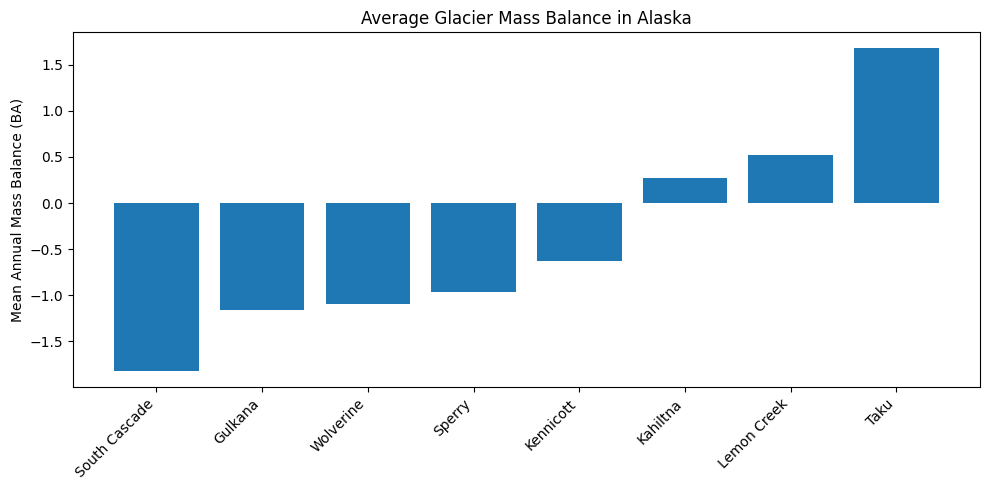

In [ ]:
ba_by_glacier_sorted = ba_by_glacier.sort_values('mean_ba')

plt.figure(figsize=(10, 5))
plt.bar(ba_by_glacier_sorted['glacier_name'], ba_by_glacier_sorted['mean_ba'])
plt.xticks(rotation=45, ha='right')
plt.ylabel("Mean Annual Mass Balance (BA)")
plt.title("Average Glacier Mass Balance in Alaska")
plt.tight_layout()
plt.show()

This data shows that anually most of the glacier accumulate a mass balance of around -0.5 to -1.0. With a few outliers ranging from 0.0 to 1.5. Although this provides a good average visualization of the mean annual mass balance, we should be looking at the annual mass balance.

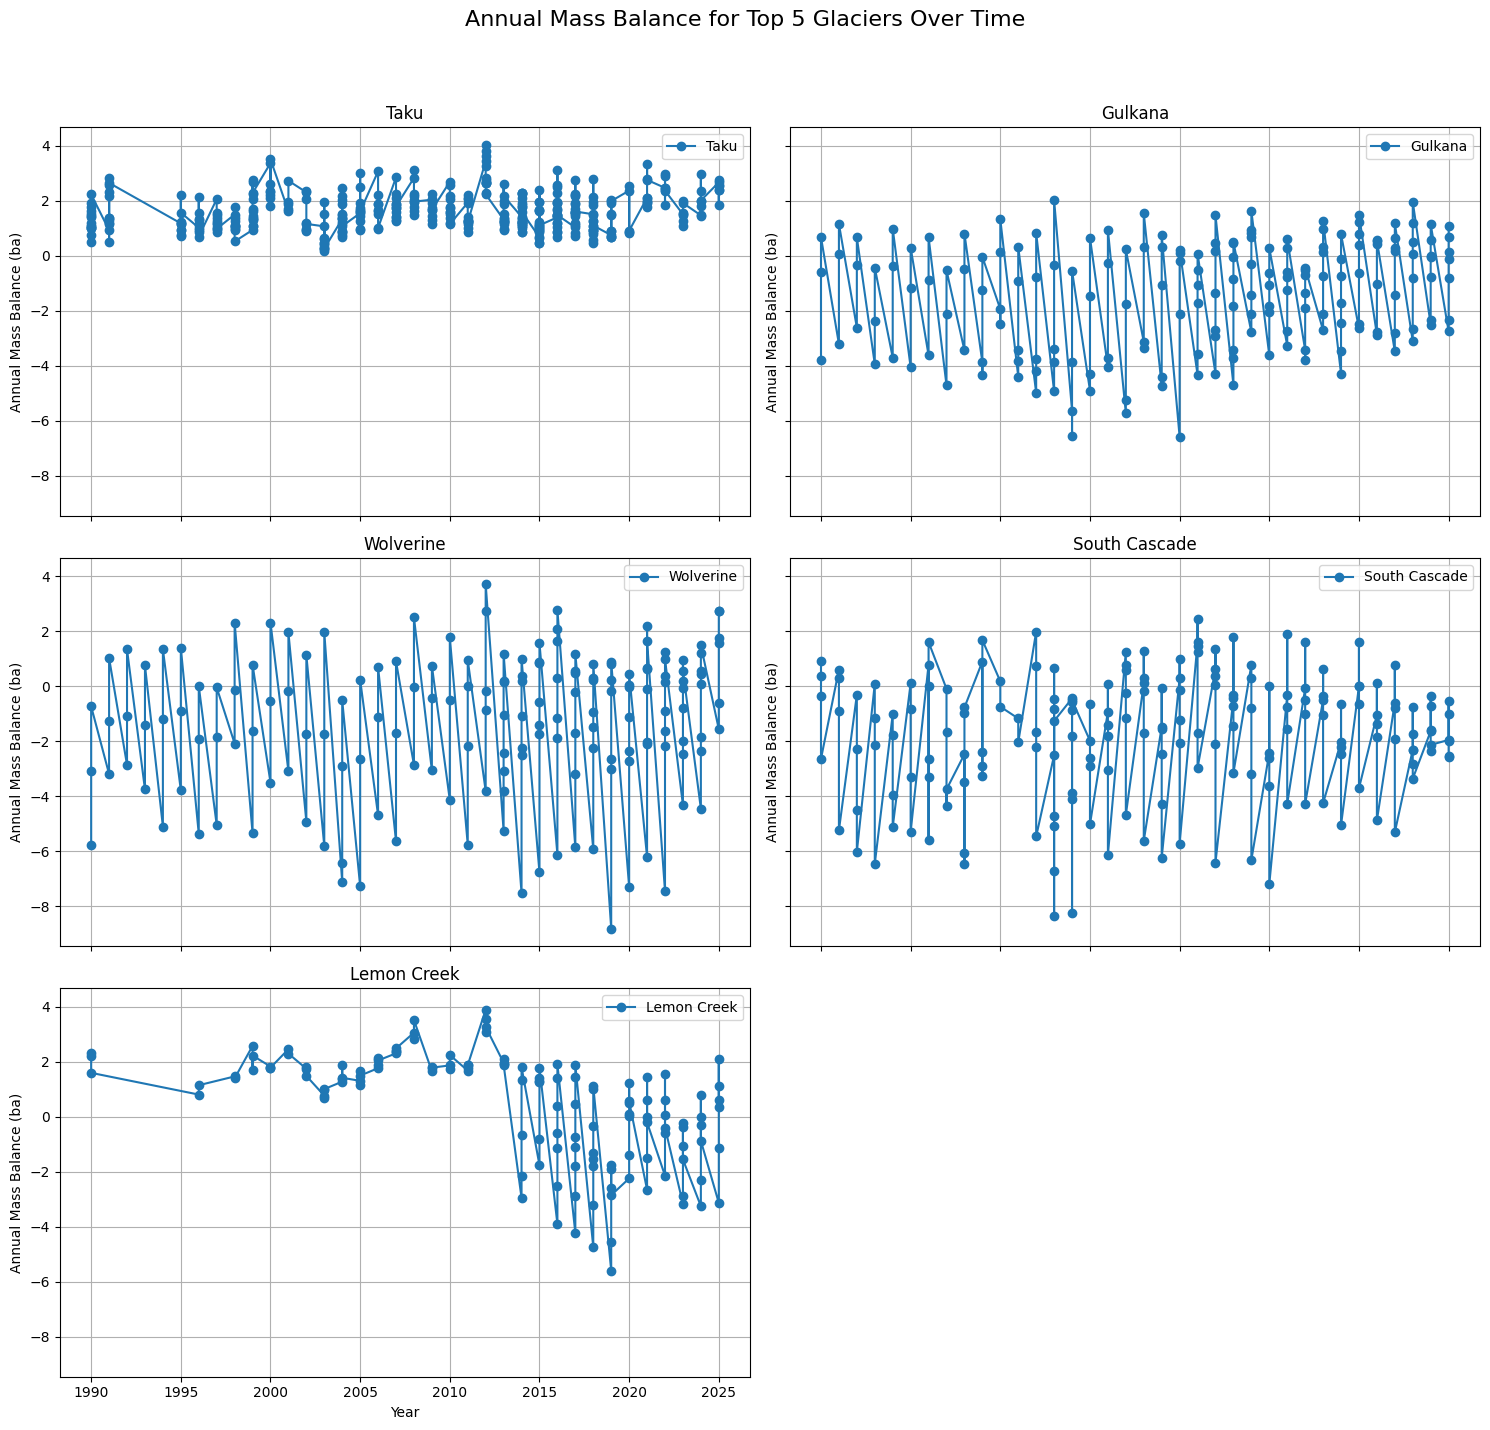

In [ ]:
clean = alaska_glaciers.dropna(subset=['ba'])
top_glaciers = clean['glacier_name'].value_counts().head(5).index

num_glaciers = len(top_glaciers)
num_cols = 2
num_rows = (num_glaciers + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 5 * num_rows), sharex=True, sharey=True)
axes = axes.flatten()

fig.suptitle('Annual Mass Balance for Top 5 Glaciers Over Time', fontsize=16)

for i, glacier_name in enumerate(top_glaciers):
    glacier_data = clean[clean['glacier_name'] == glacier_name].sort_values('Year')
    glacier_data = glacier_data[glacier_data['Year'] >= 1990]
    axes[i].plot(glacier_data['Year'], glacier_data['ba'], marker='o', label=glacier_name)
    axes[i].set_title(f'{glacier_name}')
    axes[i].set_ylabel('Annual Mass Balance (ba)')
    axes[i].grid(True)
    axes[i].legend()

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.xlabel('Year')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

A for loop was used to create the template of each of the graphs and plot the respective data to each. Trying to plot all the data on one graph make it unreadable, and hard for analysis, thus this approach was used.

Using the graphs created, it can be seen that the mass balance accumulation for almost all the glaciers is clustered. Some glaciers for instance, Lemon Creek has a large dip in mass accumulation around 2013. A similar dip in mass accumulation can be observed in the data for South Cascade glacier in 2003.



# **CO2 Emissions**

**Zackary Caufield**

In order to investigate glacier change over time we need to investigate some of the potential factors that could be impacting these glaciers. In order to do so we will investigate the level of carbon from the United States as well as average temperature. This data will also be filtered in order to follow our timeline of 1990-2024.


In [ ]:
co2_df = pd.read_csv(co2_url)
final_co2df = co2_df[(co2_df['year'] >= 1990) & (co2_df['year'] <= 2024)][['year', 'population', 'co2', 'co2_growth_prct', 'temperature_change_from_co2']]
final_co2df.head()

,year,population,co2,co2_growth_prct,temperature_change_from_co2
15,1990,253373387.0,5131.760742,3.457963,0.161026
16,1991,256471424.0,5076.412598,-1.078540,0.163407
17,1992,259606021.0,5178.769531,2.016330,0.165815
18,1993,262633229.0,5279.520020,1.945460,0.168263
19,1994,265474811.0,5361.863281,1.559663,0.170764


In order to view the impact of carbon emissions over time, we will look at the average temperature change every year due to these emissions.


In [ ]:
average_temp_change = final_co2df['temperature_change_from_co2'].mean()

years = list(range(1990, 2025))
average_temp_df = pd.DataFrame({
    'year': years,
    'average_temperature_change': [average_temp_change] * len(years)
})

print("Average temperature change from CO2:", average_temp_change)
average_temp_df.head()

Average temperature change from CO2: 0.2048346506697791


,year,average_temperature_change
0,1990,0.204835
1,1991,0.204835
2,1992,0.204835
3,1993,0.204835
4,1994,0.204835


As shown here, the average change in temperature from carbon emissions is about 0.204 degrees per year, which in small increments is inconsequential, however overtime will cause a great impact on the environment and the conditions and longevity of these glaciers.



We must also look at the change over time in temperatures caused by carbon.


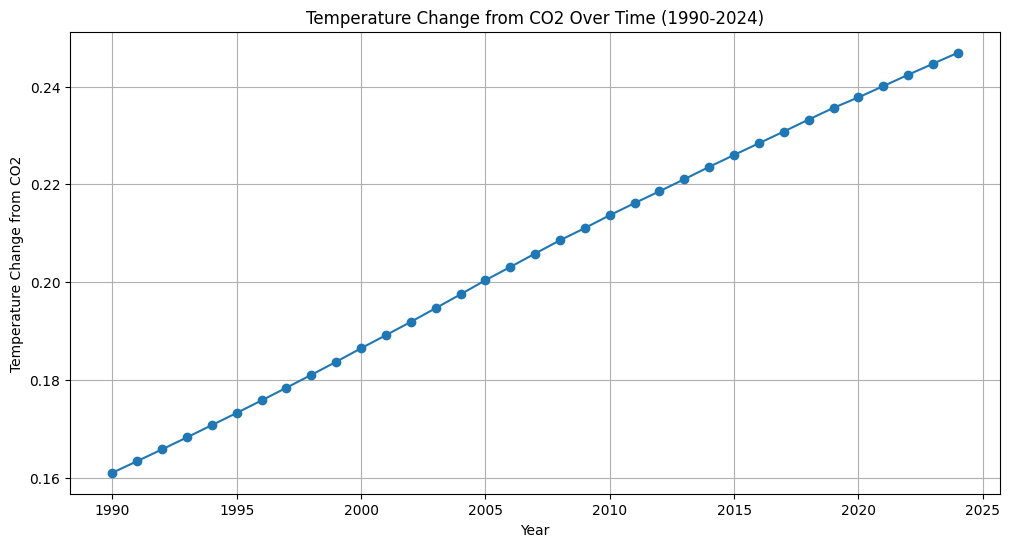

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(final_co2df['year'], final_co2df['temperature_change_from_co2'], marker='o', linestyle='-')
plt.title('Temperature Change from CO2 Over Time (1990-2024)')
plt.xlabel('Year')
plt.ylabel('Temperature Change from CO2')
plt.grid(True)
plt.show()

In order to investigate a possible correlatory relationship between the temperature change over time and carbon growth percentage levels released by the US, we will use matplotlib to create a graph in order to view this relationship as well as calculate the correlation between CO2 growth percentage as well as temperature change over time.


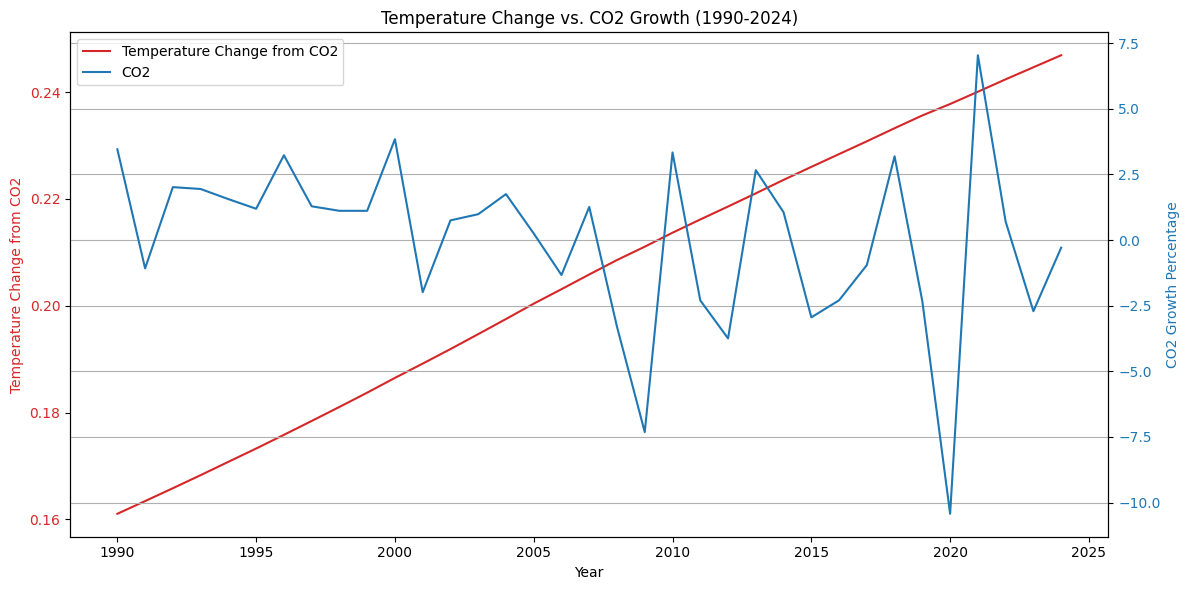

In [ ]:
fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.plot(final_co2df['year'], final_co2df['temperature_change_from_co2'], color='tab:red', label='Temperature Change from CO2')
ax1.set_xlabel('Year')
ax1.set_ylabel('Temperature Change from CO2', color='tab:red')
ax1.tick_params(axis='y', labelcolor='tab:red')

ax2 = ax1.twinx()
ax2.plot(final_co2df['year'], final_co2df['co2_growth_prct'], color='tab:blue', label='CO2')
ax2.set_ylabel('CO2 Growth Percentage', color='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:blue')
plt.title('Temperature Change vs. CO2 Growth (1990-2024)')
fig.tight_layout()
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

plt.grid(True)
plt.show()

In [ ]:
correlation = final_co2df['co2_growth_prct'].corr(final_co2df['temperature_change_from_co2'])
print(f"Correlation between CO2 Growth Percentage and Temperature Change: {correlation:.4f}")

Correlation between CO2 Growth Percentage and Temperature Change: -0.3221


The correlation between CO2 Growth Percentage and Temperature Change is calculated as -0.3221. This indicates a negative correlation between the two, meaning that as CO2 growth percentage increases, the temperature change from CO2 tends to slightly decrease, and vice-versa, but the relationship is not very strong.


Overall this shows that CO2 growth is playing a factor in temperature change but not a very major one. However, temperature change from carbon itself is consistantly rising due to the growing levels of carbon present over time. This of course, has a great impact on glacier size and location due to the inconsistant temperatures and weather events caused by global climate change.


In order to understand sea levels rising, we have to understand why glaciers melt. Looking at temperature changes gives a strong indication of how fluctuations in temperatures directly affect the surrounding glaciers in Alaska. When annual average temperatures rise glaciers absorb more heat than seasonal snowfall can replenish, tipping the balance from accumulation to melt.

# Average U.S. Surface Temperature
Gioia Bonanno

In [ ]:
avg_surface_temp = pd.read_csv(surface_temp)
avg_surface_temp = avg_surface_temp[(avg_surface_temp['Code'] == 'USA') & (avg_surface_temp['year'] >= 1990)]

# Convert to Fahrenheit
avg_surface_temp['avg_temp_f'] = (avg_surface_temp['Average surface temperature'] * 9/5) + 32

# Group by year and keep entity/code columns
avg_surface_temp_annual = avg_surface_temp.groupby(['Entity', 'Code', 'year']).agg(
    avg_surface_temp_f=('avg_temp_f', 'mean'),
).reset_index()

avg_surface_temp_annual.head()

,Entity,Code,year,avg_surface_temp_f
0,United States,USA,1990,49.041371
1,United States,USA,1991,48.919819
2,United States,USA,1992,48.059558
3,United States,USA,1993,47.829737
4,United States,USA,1994,48.673540


This data comes from *Our World In Data*, in which it is being used in this project to explain the average monthly surface temperature for the United States. *Our World In Data* works as a collaborative effort between researchers at the University of Oxford, to understand and explain global world problems through data.

The original data set, included monthly average temperatures from almost every country in Celcius, dating back to 1941. In order to make it more consistent with the rest of this project, I cleaned and reorganized the data to only display data from the United states from the dates 1990-present and did a conversion calculation to convert the temperatures to Farenheit.


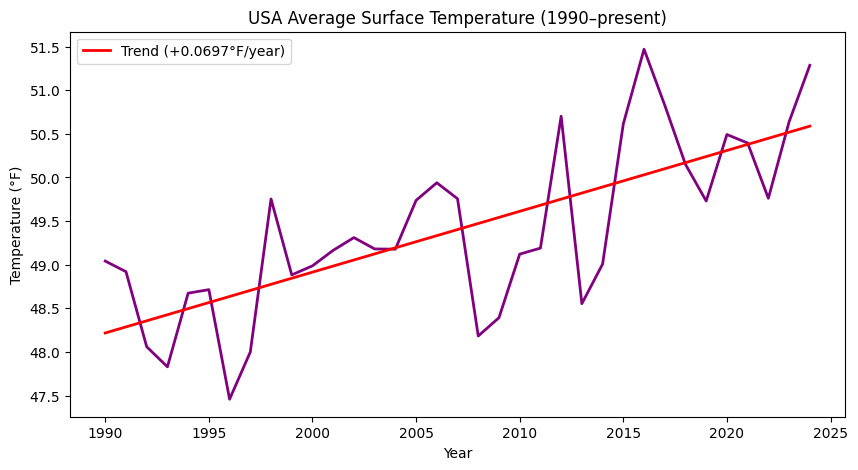

In [ ]:
avg_surface_temp_annual = avg_surface_temp.groupby('year')['avg_temp_f'].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 5))

slope, intercept, r_value, p_value, std_err = stats.linregress(avg_surface_temp_annual['year'], avg_surface_temp_annual['avg_temp_f'])
trendline = slope * avg_surface_temp_annual['year'] + intercept

ax.plot(avg_surface_temp_annual['year'], avg_surface_temp_annual['avg_temp_f'],
        color='purple', linewidth=2)

ax.plot(avg_surface_temp_annual['year'], trendline,
        color='red', linewidth=2, linestyle='-', label=f'Trend (+{slope:.4f}°F/year)')
ax.legend()

ax.set_xlabel('Year')
ax.set_ylabel('Temperature (°F)')
ax.set_title('USA Average Surface Temperature (1990–present)')

plt.show()

As surface temperatures across the United States have steadily risen since 1990, the graph above makes this warming trend visually clear. The purple line represents the actual recorded annual average temperature each year, zigzagging up and down as expected due to natural year-to-year climate variability. The red line represents the clear consistent upward climb of +0.0697°F per year. Temperatures in the early 1990s hovered around 48°F, while by the early 2020s they are regularly reaching above 50.5°F, representing nearly 2.4°F of total warming over just three decades.

In the more recent years, the purple line has been spending significantly more time above the trendline which reinforces that warming is not just gradual but accelerating.

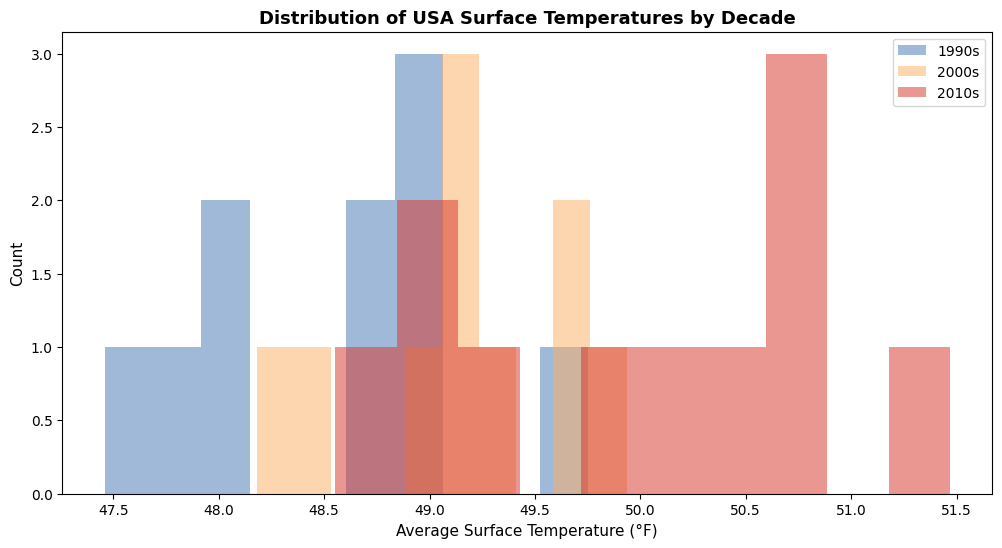

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

for year_group, label, color in zip(
    [range(1990, 2000), range(2000, 2010), range(2010, 2021)],
    ['1990s', '2000s', '2010s'],
    ['#4575b4', '#fdae61', '#d73027']
):
    subset = avg_surface_temp_annual[avg_surface_temp_annual['year'].isin(year_group)]
    ax.hist(subset['avg_temp_f'], alpha=0.5, label=label, bins=10, color=color)

ax.set_xlabel('Average Surface Temperature (°F)', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('Distribution of USA Surface Temperatures by Decade', fontsize=13, fontweight='bold')
ax.legend()
plt.show()

This graph shows the display of theaverage surface temperatures grouped by decades displayed acorss the X-axis. As the X-axis shows the temperatures, the Y-axis is the count which represents how many years had an average temperature in that range. And since each decade represents 10 years, the counts for that decade adds up to 10. For example, 1990s had 2 years that averaged around 48.0 degrees farenheit, 3 years around 49 degrees and so on.

Blue (1990s) is clustered around 47.5-49.0, mostly on the left/cooler side. Orange (2000s) is clustered around 48.5-49.5, shifting slightly right. Red (2010s) is predominantly towards the far right, spanning over the higher temperatures of 49.0-51.5.

It is clear to see that each decades distribution has gradually shifted to the right highlighting the overall warmth of our planet. The average temperatures that were rare in the 1990s became the norm in the 2010s.

# Alaska Temps
Gioia Bonanno

In [ ]:
alaska_temp = pd.read_csv(alaska_temp, skiprows=7,
                         names=['year', 'max_temp_f', 'max_temp_date', 'min_temp_f', 'min_temp_date', 'avg_temp_f']
)

alaska_temp['year'] = pd.to_numeric(alaska_temp['year'], errors='coerce')
alaska_temp.dropna(subset=['year'], inplace=True)
# Convert 'year' to integer type after cleaning
alaska_temp['year'] = alaska_temp['year'].astype(int)

alaska_temp = alaska_temp[alaska_temp['year'] >= 1990]

print(alaska_temp.columns.tolist())
alaska_temp.head()

['year', 'max_temp_f', 'max_temp_date', 'min_temp_f', 'min_temp_date', 'avg_temp_f']


,year,max_temp_f,max_temp_date,min_temp_f,min_temp_date,avg_temp_f
35,1990,80,1990-08-11,-24,1990-12-01,34.8
36,1991,75,1991-06-20,-14,1991-02-07,36.8
37,1992,74,1992-07-01,-16,1992-03-05,35.5
38,1993,80,1993-07-12,-22,1993-02-02,39.0
39,1994,76,1994-08-03,-15,1994-11-25,36.4


This data comes from the Alaska Climate Research Center (ACRC), which analyzes inquiries concerning the meteorology and climatology of Alaska for public, private, and government agencies.

The original dataset is spans from 1953 to 2022, however for consistency with the USA surface temperature dataset, the data was filtered to only include years greater than or equal to 1990. This data is specific to the Anchorage, Alaska station and each row represents one full year of recordings. It includes the annual maximum temperature,the annual minimum temperature (recorded in Farenheit), the dates they were recorded, and the annual average temperature.

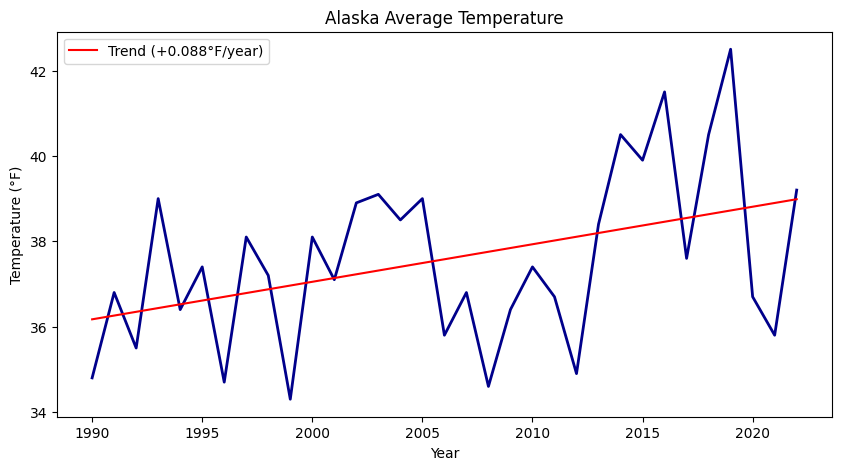

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(alaska_temp['year'], alaska_temp['avg_temp_f'], color='darkblue', linewidth=2)

slope, intercept, r_value, p_value, std_err = stats.linregress(alaska_temp['year'], alaska_temp['avg_temp_f'])
trendline = slope * alaska_temp['year'] + intercept

ax.plot(alaska_temp['year'], trendline, color='red', linestyle='-', label=f'Trend (+{slope:.3f}°F/year)')
ax.legend()

ax.set_xlabel('Year')
ax.set_ylabel('Temperature (°F)')
ax.set_title('Alaska Average Temperature')
plt.show()

The dark blue line represents the actual recorded annual average temperature in Anchorage, Alaska from 1990 to 2022, while the red trendline reveals the overall direction of change. Anchorage temperatures fluctuate dramatically year to year, with a sharp dips in 1999 and 2005 reaching 34°F and then striking peaks above 42°F in 2019. However, despite this variability, the red trendline tells a clear and concerning story, rising at a rate of +0.088°F per year. This is notably faster than the USA national average of +0.0697°F per year seen in the previous graph, confirming that Alaska is warming at a significantly greater rate than the rest of the country. Temperatures in the early 1990s hovered around 35-37°F, while by the late 2010s and early 2020s they are regularly reaching above 39-42°F, representing a substantial shift over the past three decades. This accelerated warming in Anchorage is directly relevant to glacier health causing Alaska's glaciers to lose mass year after year and contributing to the rising sea levels.

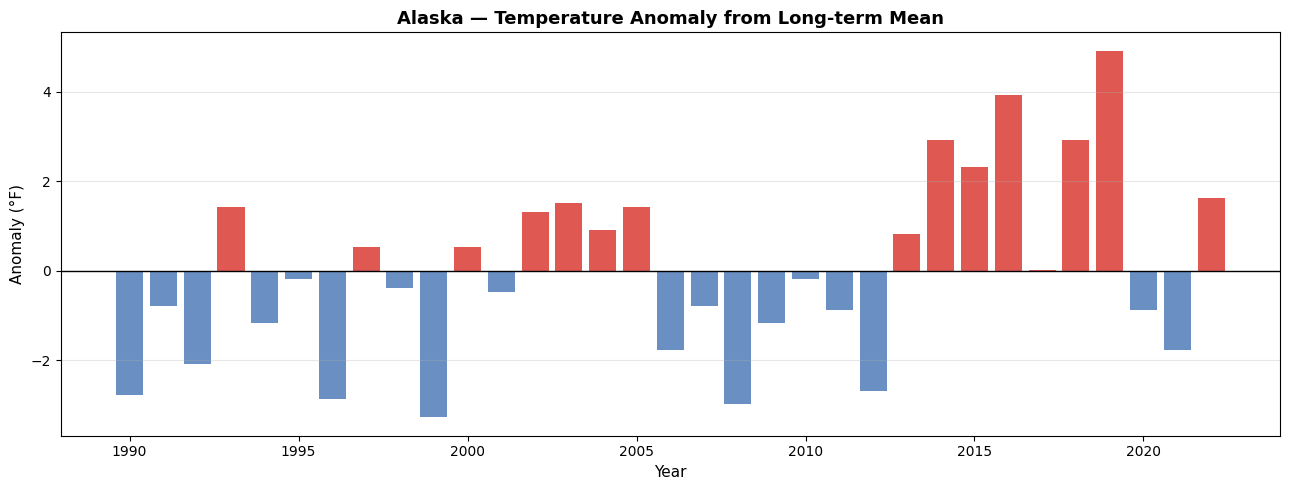

Warming rate:      0.0879°F per year
Baseline mean:     37.58°F
Most recent year:  2022 — 39.20°F


In [ ]:
fig, ax = plt.subplots(figsize=(13, 5))

baseline_ak = alaska_temp['avg_temp_f'].mean()
alaska_temp['anomaly'] = alaska_temp['avg_temp_f'] - baseline_ak

slope, intercept, r, p, se = stats.linregress(alaska_temp['year'], alaska_temp['avg_temp_f'])

colors = ['#d73027' if a >= 0 else '#4575b4' for a in alaska_temp['anomaly']]
ax.bar(alaska_temp['year'], alaska_temp['anomaly'],
       color=colors, alpha=0.8)

ax.axhline(y=0, color='black', linewidth=1)
ax.set_title('Alaska — Temperature Anomaly from Long-term Mean', fontsize=13, fontweight='bold')
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Anomaly (°F)', fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Warming rate:      {slope:.4f}°F per year')
print(f'Baseline mean:     {baseline_ak:.2f}°F')
print(f'Most recent year:  {alaska_temp["year"].max()} — {alaska_temp[alaska_temp["year"] == alaska_temp["year"].max()]["avg_temp_f"].values[0]:.2f}°F')

This graph takes a different approach to visualizing Anchorage's warming trend by showing temperature anomalies, ,eaning how far each year's temperature deviated from the long-term baseline mean of 37.58°F, rather than the raw temperature values themselves. Each bar represents a single year, with red bars indicating years that were warmer than average and blue bars indicating years that were cooler than average. The zero line running across the middle is the baseline, and any bar extending above it means that year was unusually warm, while any bar below it means that year ran cooler than normal.

The shift in color distribution over time is the most telling feature of this graph. Through the 1990s and into the early 2000s, blue and red bars appear in relatively equal measure, highlighting a period where temporature fluctuation was relatively normal. As time progresses, towards the 2010s the red bars become increasingly dominant and increasingly tall, peaking dramatically in 2019 at nearly +5°F above the baseline.

The most recent year recorded, 2022, sits at 39.20°F, still above the long-term mean. Combined with a warming rate of +0.0879°F per year, this anomaly chart powerfully reinforces Anchorage is not just warming gradually, but that the frequency and intensity of above-average years has accelerated sharply since 2013, placing increasing stress on Alaska's glaciers.

#Our Analysis

Throughout this project, we assigned individual topics to research in order to answer the question: To what extent does the rate of cumulative mass loss differ for glaciers between Alaska and the Western United States from 1990 to 2025, and how has the frequency and magnitude of annual specific mass balance changed in relation to annual CO2 emissions and surface temperature across the United States?

Inorder to provide convencing data to answer our question, we choose to include the Lemon Creek Glacier, which has the most distincitve dip in anual mass balance.

In order to better understand our analysis, we also are inculding the graph illustrating CO2 level change over time in order to better understand the analysis done. Keeping in mind that temperature increased linearly overthis time period

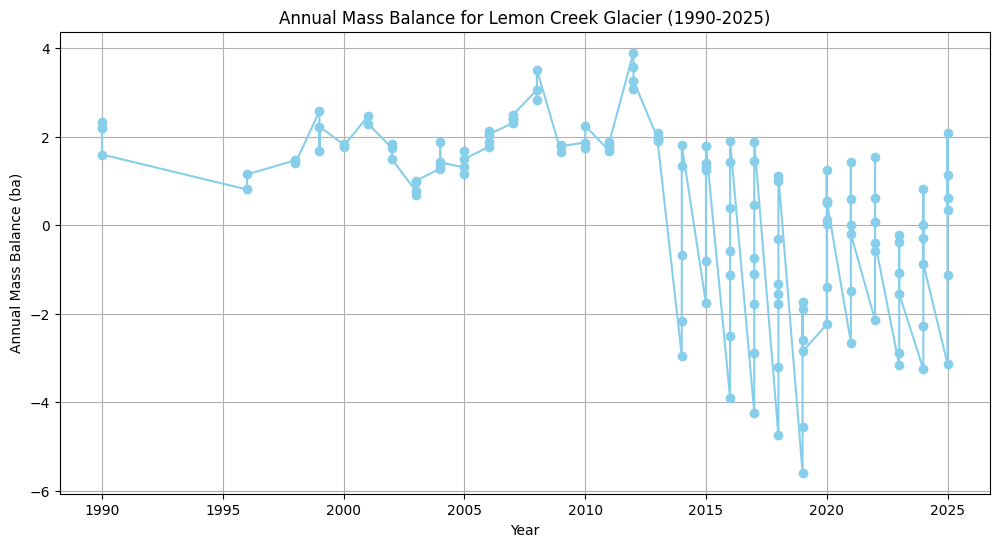

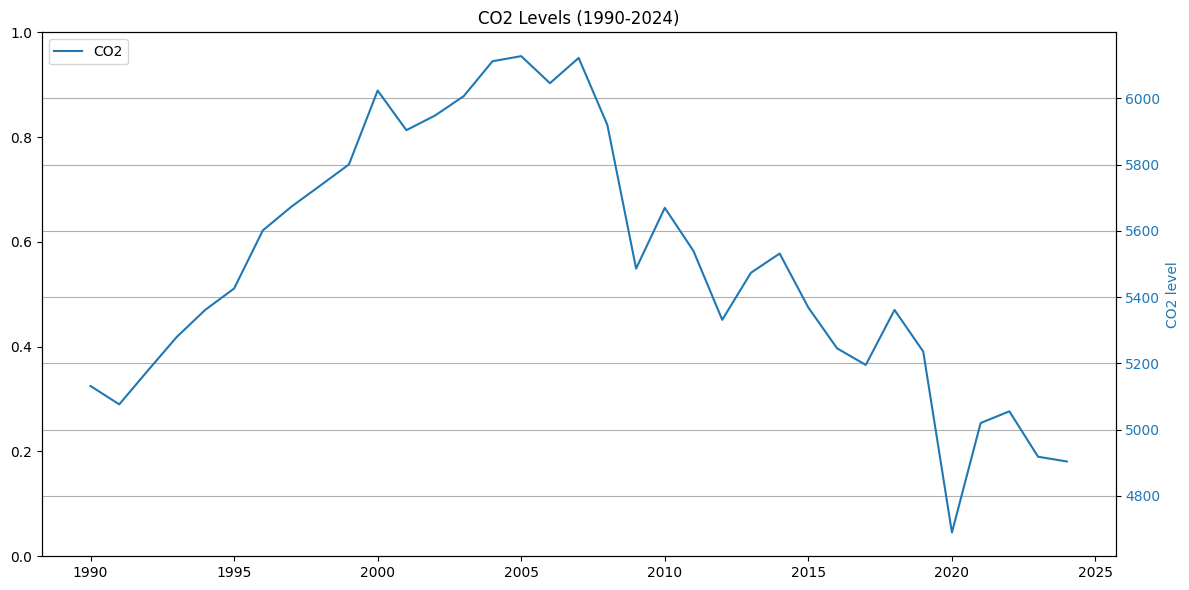

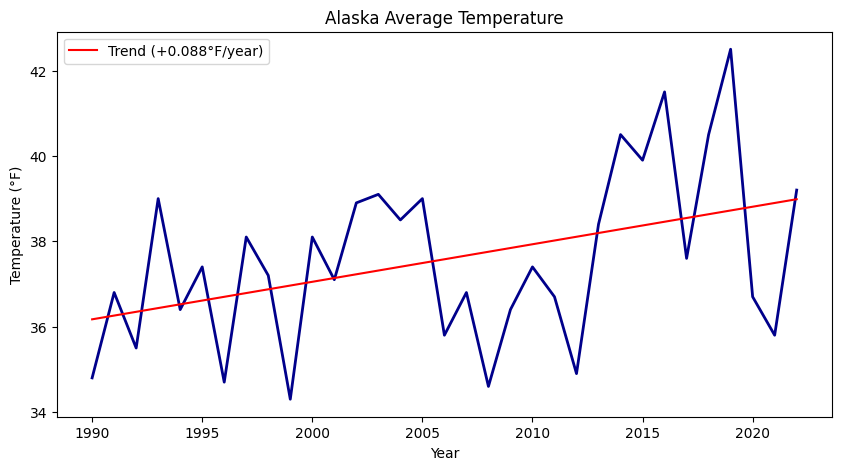

In [ ]:
lemon_creek_data = clean[(clean['glacier_name'] == 'Lemon Creek') & (clean['Year'] >= 1990) & (clean['Year'] <= 2025)].sort_values('Year')

plt.figure(figsize=(12, 6))
plt.plot(lemon_creek_data['Year'], lemon_creek_data['ba'], marker='o', linestyle='-', color='skyblue')
plt.title('Annual Mass Balance for Lemon Creek Glacier (1990-2025)')
plt.xlabel('Year')
plt.ylabel('Annual Mass Balance (ba)')
plt.grid(True)
plt.show()

fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()
ax2.plot(final_co2df['year'], final_co2df['co2'], color='tab:blue', label='CO2')
ax2.set_ylabel('CO2 level', color='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:blue')
plt.title('CO2 Levels (1990-2024)')
fig.tight_layout()
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')
plt.grid(True)
plt.show()

# alaska
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(alaska_temp['year'], alaska_temp['avg_temp_f'], color='darkblue', linewidth=2)

slope, intercept, r_value, p_value, std_err = stats.linregress(alaska_temp['year'], alaska_temp['avg_temp_f'])
trendline = slope * alaska_temp['year'] + intercept

ax.plot(alaska_temp['year'], trendline, color='red', linestyle='-', label=f'Trend (+{slope:.3f}°F/year)')
ax.legend()

ax.set_xlabel('Year')
ax.set_ylabel('Temperature (°F)')
ax.set_title('Alaska Average Temperature')
plt.show()

Comparing the graphs of annual mass balance for Lemmon Creek Glacier and atmospheric CO2 levels from 1990 to 2024, there is not sufficient cohesive evidence to conclude that CO2 levels alone caused the dramatic decline in the glacier's mass balance. However, when examining average temperatures in Alaska from 1990 to 2020, a notable increase occurs around 2007. This rise in temperature may provide stronger evidence that regional warming played a significant role in the substantial decrease in mass balance observed for Lemmon Creek Glacier around 2010.

It is important to note that these observations for Lemmon Creek Glacier do not provide concrete evidence that temperature increases or CO2 levels are directly correlated with mass balance loss across all glaciers in Alaska or globally. While our observations suggest a possible relationship, glaciers respond to a wide range of local factors such as precipitation patterns, elevation, and ocean influences. Because of these varing conditions, trends observed in one glacier cannot be generalized to all glaciers.  